In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


ModuleNotFoundError: No module named 'plotly'

Faza 1: EDA (Eksploracyjna Analiza Danych)Cel: Zrozumienie, co napędza Twój biznes i gdzie uciekają pieniądze.Zadania do wykonania:

Analiza Rankingowa: Stwórz zestawienie "Top 5 marek" oraz "Top 5 kategorii produktów" pod względem całkowitego przychodu ($Revenue$).

Sezonowość i Anomalie: Wygeneruj wykres liniowy sprzedaży w czasie. Czy widzisz nagłe skoki (np. Black Friday, okres przedświąteczny)?
Rentowność Kanałów: Porównaj średnią wartość marży ($Profit Margin$) dla sprzedaży online vs. stacjonarnej.Który kanał jest bardziej zyskownny?
Geografia: Stwórz mapę ciepła (Heatmap), która pokaże, w których krajach konkretne marki sprzedają się najlepiej (np. czy marka X dominuje we Francji, a marka Y w USA?).F

In [38]:
df = pd.read_csv('makeup_sales_dataset_2025.csv')

In [3]:
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76


In [4]:
df.isna().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.dtypes

Sale_ID                    int64
Date              datetime64[us]
Brand                        str
Product_Type                 str
Country                      str
Sales_Channel                str
Payment_Method               str
Price_USD                float64
Units_Sold                 int64
Revenue_USD              float64
dtype: object

In [39]:
df['Date'] = pd.to_datetime(df['Date'], yearfirst=True, errors='raise')

Analiza Rankingowa: Stwórz zestawienie "Top 5 marek" oraz "Top 5 kategorii produktów" pod względem całkowitego przychodu ($Revenue$).

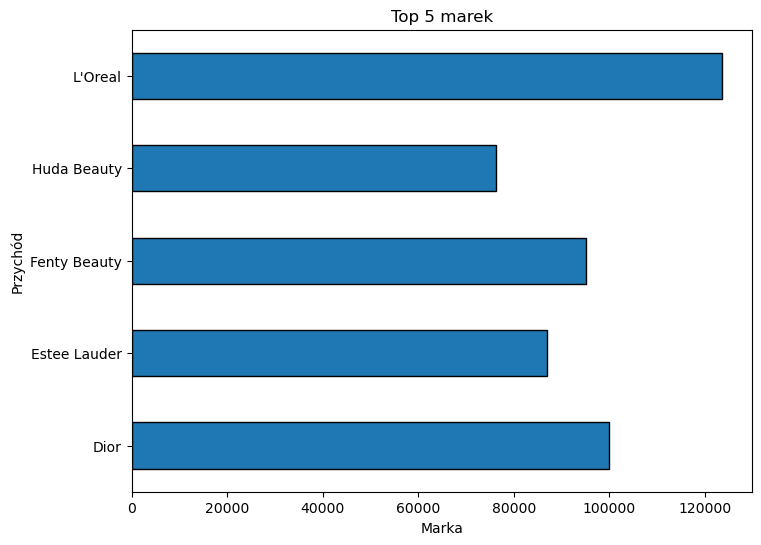

In [17]:
plt.figure(figsize=(8,6))
ax = df.groupby(by='Brand')['Revenue_USD'].sum().head(5).plot(kind='barh', edgecolor = 'black')
plt.xlabel('Marka')
plt.ylabel('Przychód')
plt.title('Top 5 marek')
plt.show()

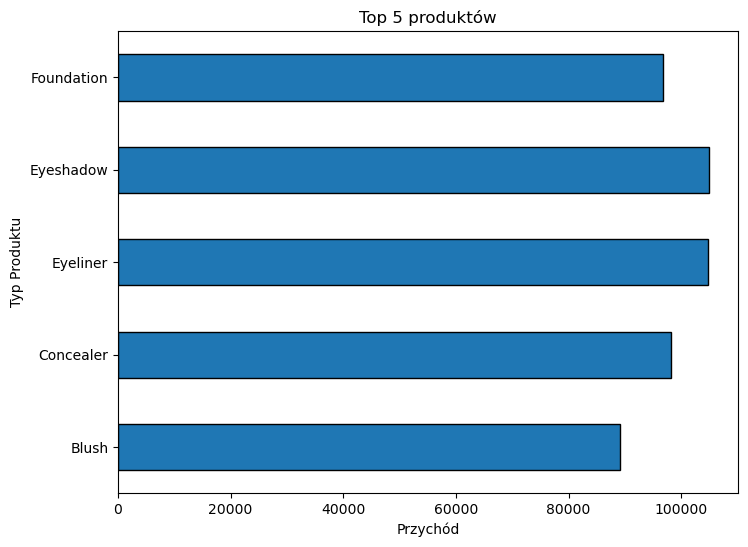

In [21]:
plt.figure(figsize=(8,6))
ax = df.groupby(by= 'Product_Type')['Revenue_USD'].sum().head(5).plot(kind='barh', edgecolor = 'black')
plt.xlabel('Przychód')
plt.ylabel('Typ Produktu')
plt.title('Top 5 produktów')
plt.show()

Sezonowość i Anomalie: Wygeneruj wykres liniowy sprzedaży w czasie. Czy widzisz nagłe skoki (np. Black Friday, okres przedświąteczny)?

In [40]:
df = df.set_index('Date')
df = df.sort_index()

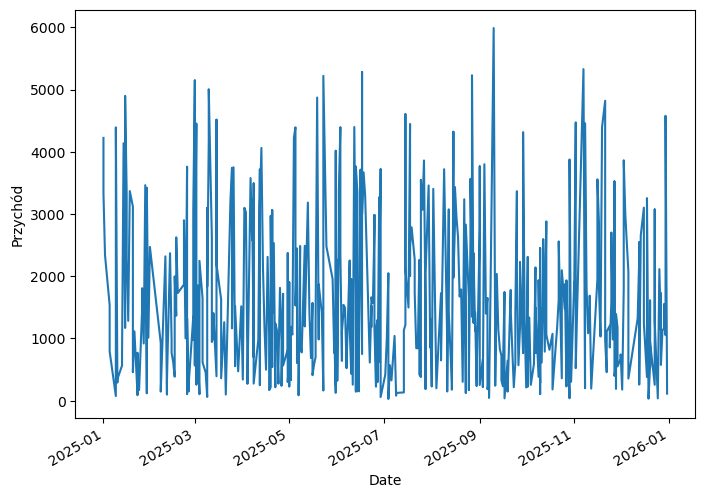

In [43]:
plt.figure(figsize=(8,6))
ax =df['Revenue_USD'].plot(kind= 'line')
plt.ylabel('Przychód')
plt.xlabel('Date')
plt.show()

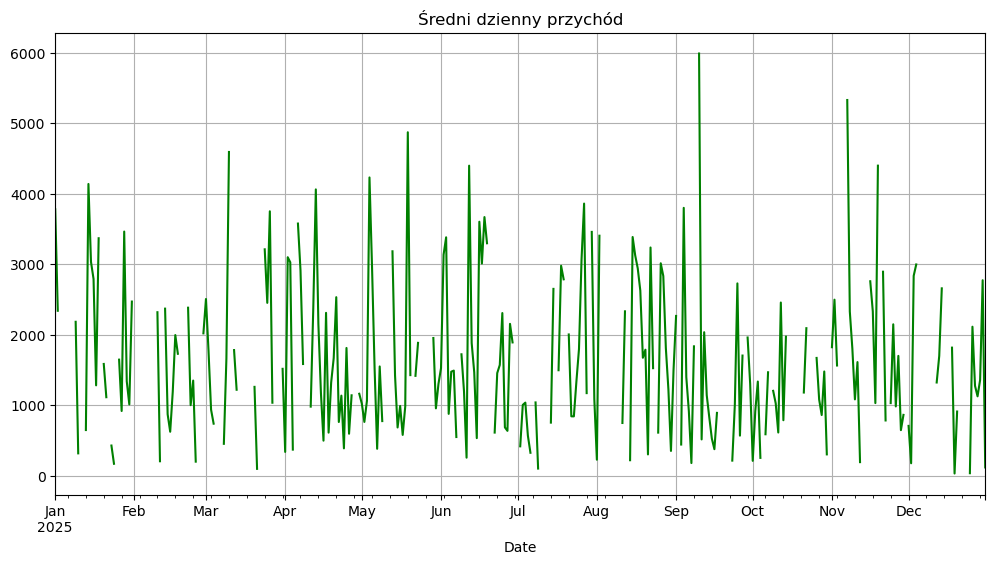

In [53]:
df_clean = df['Revenue_USD'].resample('D').mean()

df_clean.plot(figsize=(12, 6), color='green')
plt.title('Średni dzienny przychód')
plt.grid(True)
plt.show()

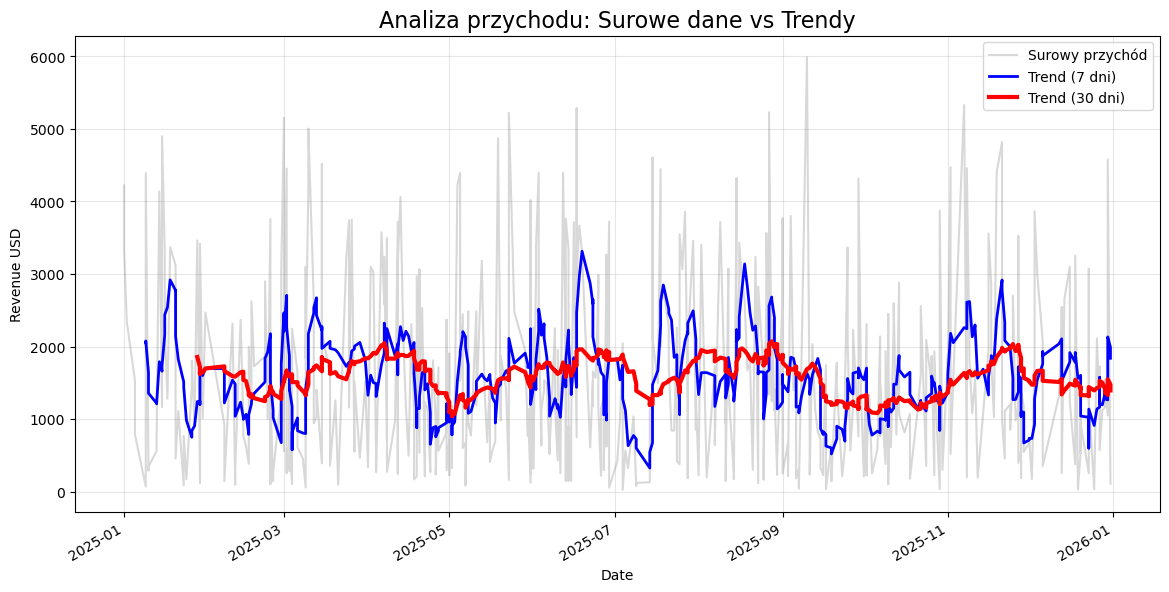

In [54]:
import matplotlib.pyplot as plt

# 1. Oryginalne dane (lekko przeźroczyste, żeby nie przytłaczały)
ax = df['Revenue_USD'].plot(figsize=(14, 7), alpha=0.3, color='gray', label='Surowy przychód')

# 2. Średnia krocząca z 7 dni (wygładzony trend tygodniowy)
df['Revenue_USD'].rolling(window=7).mean().plot(ax=ax, color='blue', linewidth=2, label='Trend (7 dni)')

# 3. Średnia krocząca z 30 dni (trend miesięczny - bardzo gładki)
df['Revenue_USD'].rolling(window=30).mean().plot(ax=ax, color='red', linewidth=3, label='Trend (30 dni)')

plt.title('Analiza przychodu: Surowe dane vs Trendy', fontsize=16)
plt.ylabel('Revenue USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

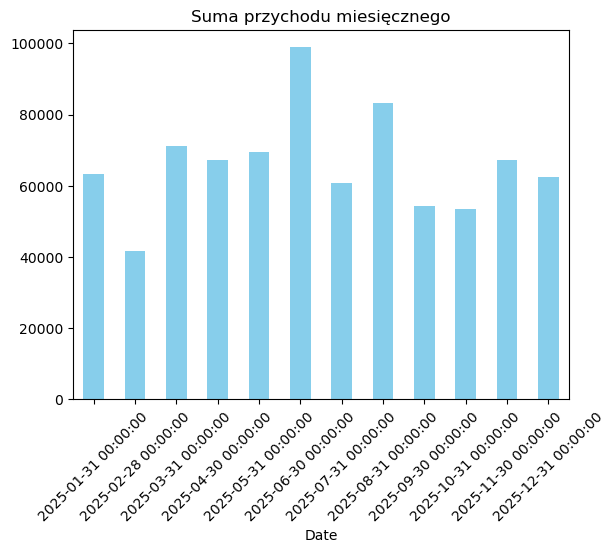

In [56]:
monthly_revenue = df['Revenue_USD'].resample('ME').sum()

monthly_revenue.plot(kind='bar', color='skyblue')
plt.title('Suma przychodu miesięcznego')
plt.xticks(rotation=45)
plt.show()

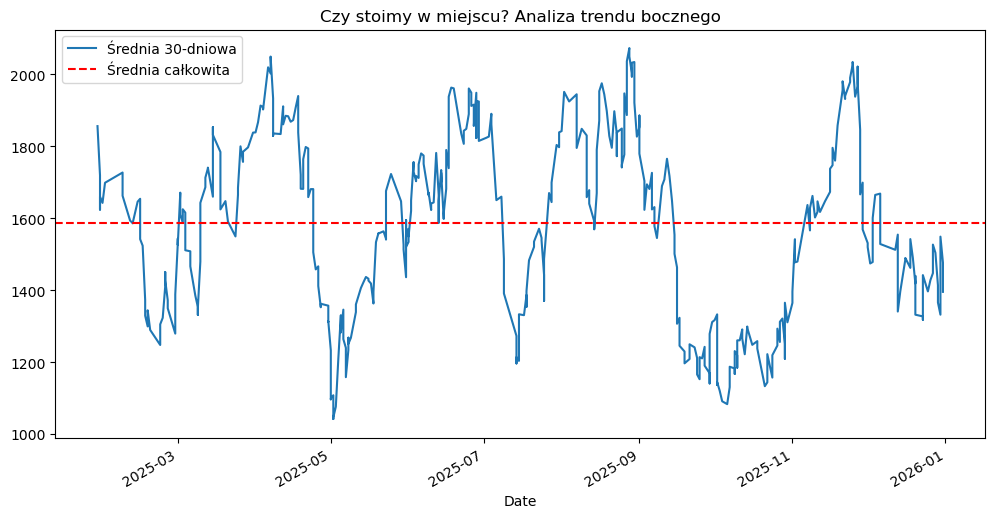

In [ ]:
# Aby sprawdzić, czy to faktycznie "stanie w miejscu", nałóż na to linię trendu (regresję). To jedna linia, która pokaże Ci, czy to pofalowanie ma choćby minimalne nachylenie.

# Możesz to zrobić bardzo prosto, dodając linię średniej z całego okresu:

ax = df['Revenue_USD'].rolling(window=30).mean().plot(figsize=(12,6), label='Średnia 30-dniowa')

# Dodajemy linię średniej ogólnej (poziom odniesienia)
plt.axhline(y=df['Revenue_USD'].mean(), color='red', linestyle='--', label='Średnia całkowita')

plt.title('Czy stoimy w miejscu? Analiza trendu bocznego')
plt.legend()
plt.show()